<a href="https://colab.research.google.com/github/AdithiJRao/Student-Performance-Prediction-/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
from google.colab import files
uploaded = files.upload()

Saving student-mat.csv to student-mat (1).csv


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
import pandas as pd

df = pd.read_csv('student-mat.csv', sep=';')

print(df.shape)
df.head()

(395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [77]:
df['Final_Result'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

df[['G3','Final_Result']].head()

,G3,Final_Result
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1


In [58]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   school        395 non-null    object
 1   sex           395 non-null    object
 2   age           395 non-null    int64 
 3   address       395 non-null    object
 4   famsize       395 non-null    object
 5   Pstatus       395 non-null    object
 6   Medu          395 non-null    int64 
 7   Fedu          395 non-null    int64 
 8   Mjob          395 non-null    object
 9   Fjob          395 non-null    object
 10  reason        395 non-null    object
 11  guardian      395 non-null    object
 12  traveltime    395 non-null    int64 
 13  studytime     395 non-null    int64 
 14  failures      395 non-null    int64 
 15  schoolsup     395 non-null    object
 16  famsup        395 non-null    object
 17  paid          395 non-null    object
 18  activities    395 non-null    object
 19  nursery 

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


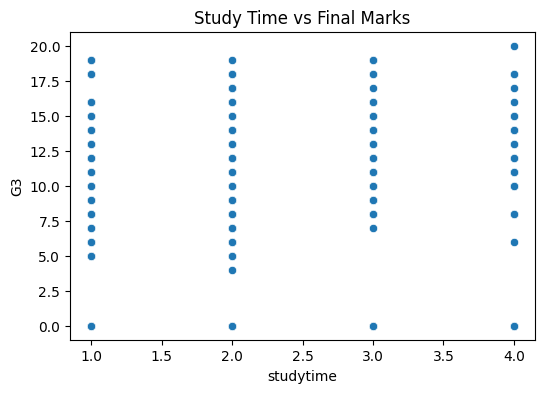

In [78]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['studytime'], y=df['G3'])
plt.title("Study Time vs Final Marks")
plt.show()

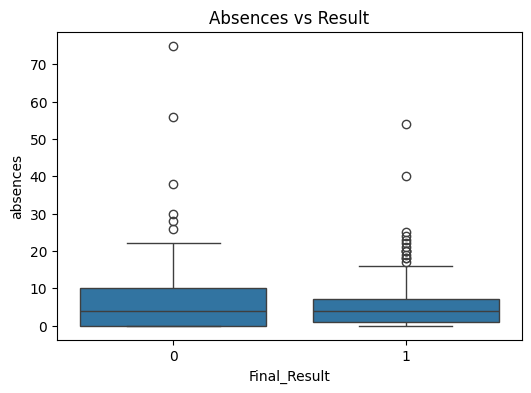

In [79]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Final_Result'], y=df['absences'])
plt.title("Absences vs Result")
plt.show()

In [80]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [81]:
X = df[['studytime', 'absences', 'G1', 'G2']]
y = df['Final_Result']

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# SVM
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)


Logistic Regression
Accuracy: 0.8987341772151899
Precision: 0.9583333333333334
Recall: 0.8846153846153846
F1 Score: 0.92


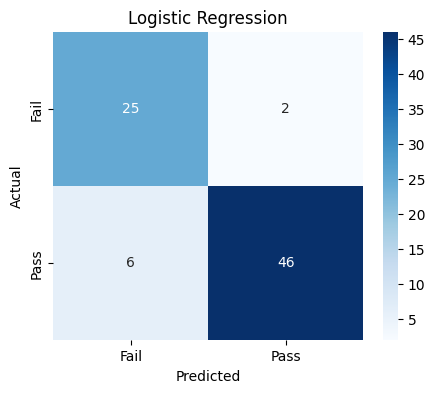


Decision Tree
Accuracy: 0.9113924050632911
Precision: 0.9411764705882353
Recall: 0.9230769230769231
F1 Score: 0.9320388349514563


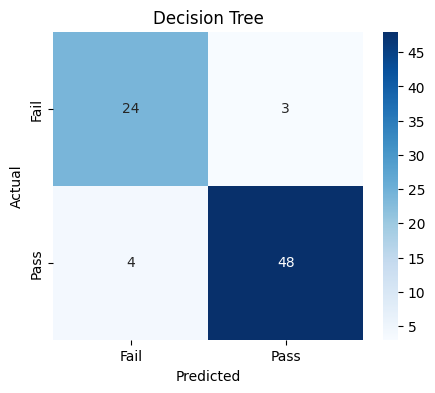


Naive Bayes
Accuracy: 0.8734177215189873
Precision: 0.9375
Recall: 0.8653846153846154
F1 Score: 0.9


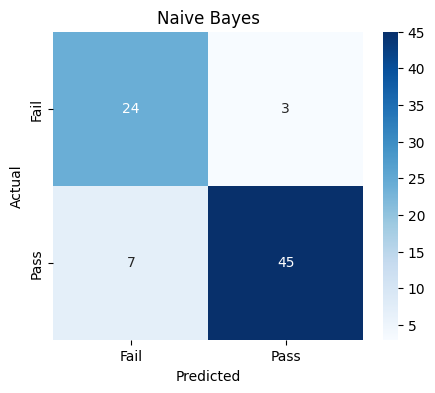


SVM
Accuracy: 0.8987341772151899
Precision: 0.94
Recall: 0.9038461538461539
F1 Score: 0.9215686274509803


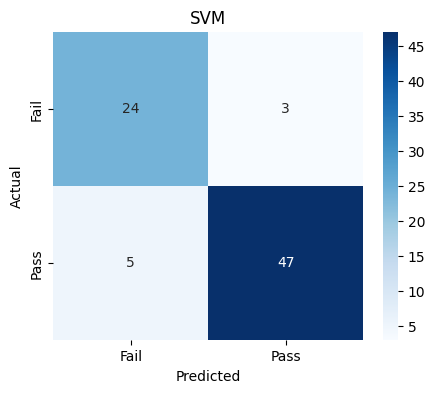

In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fail','Pass'],
                yticklabels=['Fail','Pass'])
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_nb, "Naive Bayes")
evaluate(y_test, y_pred_svm, "SVM")

In [88]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Naive Bayes", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_svm)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_svm)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_svm)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.898734,0.958333,0.884615,0.920000
1,Decision Tree,0.911392,0.941176,0.923077,0.932039
2,Naive Bayes,0.873418,0.937500,0.865385,0.900000
3,SVM,0.898734,0.940000,0.903846,0.921569


In [89]:
# Convert test data back to DataFrame
test_df = pd.DataFrame(X_test, columns=['studytime','absences','G1','G2'])

test_df['Actual'] = y_test.values
test_df['Predicted'] = y_pred_lr  # use best model

# At-risk students (Predicted Fail)
at_risk = test_df[test_df['Predicted'] == 0]

print("Number of At-Risk Students:", len(at_risk))
at_risk.head()

Number of At-Risk Students: 31


,studytime,absences,G1,G2,Actual,Predicted
0,-1.254553,-0.464408,-0.913385,-0.707176,1,0
2,-0.056853,0.249139,-2.470179,-1.507180,0,0
3,-0.056853,0.249139,-0.913385,-0.440508,1,0
4,-0.056853,0.605913,-0.602026,-0.440508,0,0
7,-0.056853,1.438384,-0.602026,-0.973844,0,0


In [90]:
test_df['Status'] = test_df['Predicted'].apply(
    lambda x: "At Risk" if x == 0 else "Safe"
)

test_df.head()

,studytime,absences,G1,G2,Actual,Predicted,Status
0,-1.254553,-0.464408,-0.913385,-0.707176,1,0,At Risk
1,-1.254553,-0.345483,0.954768,0.359495,1,1,Safe
2,-0.056853,0.249139,-2.470179,-1.507180,0,0,At Risk
3,-0.056853,0.249139,-0.913385,-0.440508,1,0,At Risk
4,-0.056853,0.605913,-0.602026,-0.440508,0,0,At Risk


In [91]:
new_student = [[3, 5, 10, 12]]

new_student_scaled = scaler.transform(new_student)

prediction = lr.predict(new_student_scaled)

print("Prediction:", "Pass" if prediction[0] == 1 else "Fail")

Prediction: Pass
